In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.special import kn as Bessel_Kn
from cpp_modules._tau_matrix_monte_carlo import tau_matrix_monte_carlo_engine as tau_gen
import cpp_modules._units as units
from tabulate import tabulate
import copy

In [2]:
energy_groups_center_menahem=[
    7.363e-11,
    2.807e-10,
    7.2562e-10,
    1.6022e-9,
    2.3592e-9,
    3.5376e-9,
    5.5118e-9,
    9.143e-9,
    1.6667e-8,
    2.3616e-8,
    3.4863e-8,
    3.8712e-8,
    4.3125e-8,
    4.8203e-8,
    5.407e-8,
    6.0876e-8,
    6.8804e-8,
    7.8082e-8,
    8.8989e-8,
    1.0187e-7,
    1.1717e-7,
    1.3542e-7,
    1.5733e-7,
    1.8377e-7,
    2.1587e-7,
    2.5509e-7,
    3.0332e-7]

energy_groups_boundaries_menahem=[
    1.3806e-16,
    1.2713e-10,
    4.2038e-10,
    1.1407e-9,
    1.8957e-9,
    2.7936e-9,
    4.2159e-9,
    6.6415e-9,
    1.2537e-8,
    1.9273e-8,
    3.0367e-8,
    3.6654e-8,
    4.0762e-8,
    4.5478e-8,
    5.0916e-8,
    5.7209e-8,
    6.4524e-8,
    7.3062e-8,
    8.3074e-8,
    9.4868e-8,
    1.0883e-7,
    1.2545e-7,
    1.4533e-7,
    1.6924e-7,
    1.9818e-7,
    2.3347e-7,
    2.7657e-7,
    1.6022e-5
]


In [3]:
energy_groups_center=copy.deepcopy(energy_groups_center_menahem)

energy_groups_boundaries=[
    3.7706e-11,
    1.5924e-10,
    4.6650e-10,
    1.0769e-9,
    1.9998e-9,
    2.9268e-9,
    4.4149e-9,
    7.0069e-9,
    1.2009e-8,
    2.0269e-8,
    2.8953e-8,
    3.7945e-8,
    4.2061e-8,
    4.6788e-8,
    5.2238e-8,
    5.8546e-8,
    6.5880e-8,
    7.4441e-8,
    8.4482e-8,
    9.6312e-8,
    1.1032e-7,
    1.2699e-7,
    1.4694e-7,
    1.7095e-7,
    2.0001e-7,
    2.3539e-7,
    2.7876e-7,
    3.3227e-7
]

print(len(energy_groups_boundaries))

28


In [8]:
# T = 2.0*units.me_c2 / units.k_boltz
T = 10.*units.kev_to_kelvin
tau = tau_gen(energy_groups_center=energy_groups_center, energy_groups_boundaries=energy_groups_boundaries, num_of_samples=20000, force_detailed_balance=True)
tau_mat = tau.generate_S_matrix(temperature=T)
table = tabulate(tau_mat, headers=energy_groups_center, floatfmt=".5g", numalign="left", )
print(table)

7.363e-11    2.807e-10    7.2562e-10    1.6022e-09    2.3592e-09    3.5376e-09    5.5118e-09    9.143e-09    1.6667e-08    2.3616e-08    3.4863e-08    3.8712e-08    4.3125e-08    4.8203e-08    5.407e-08    6.0876e-08    6.8804e-08    7.8082e-08    8.8989e-08    1.0187e-07    1.1717e-07    1.3542e-07    1.5733e-07    1.8377e-07    2.1587e-07    2.5509e-07    3.0332e-07
-----------  -----------  ------------  ------------  ------------  ------------  ------------  -----------  ------------  ------------  ------------  ------------  ------------  ------------  -----------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------
6.3393e-25   3.1596e-26   0             0             0             0             0             0            0             0             0             0             0             0             0            0             0             0             0       

In [9]:
temperature_grid = np.array([1e-2, 1., 3., 4., 6., 10., 20., 30., 40., 60., 80., 100.])
temperature_grid = temperature_grid*units.kev_to_kelvin

tau.generate_S_log_tables(temperature_grid=temperature_grid)

In [10]:
15.*units.kev_to_kelvin

174061342.14528865

In [11]:
mat = tau.generate_tau_matrix(temperature=15.*units.kev_to_kelvin, density=0.77, A=4.011, Z=2.)
table = tabulate(mat, headers=np.linspace(1.0, len(energy_groups_center), len(energy_groups_center)), floatfmt=".5g", numalign="left", )
print(table)

1.0        2.0         3.0         4.0         5.0         6.0         7.0         8.0         9.0         10.0        11.0        12.0        13.0        14.0        15.0        16.0        17.0        18.0        19.0        20.0        21.0        22.0        23.0        24.0        25.0        26.0        27.0
---------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------  ----------
0.14224    0.011326    0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0
0.0003109  0.13798     0.014771    0.00026404  0 

In [ ]:
help(tau_gen)
help(units)

In [ ]:
def P(x_P, theta_P):
    Db = 2*theta_P**3*np.exp(-1.0/theta_P)*(1.0 + 1.0/theta_P + 0.5/theta_P**2.0)
    return x_P**2*np.exp(-x_P/theta_P)/Db

def MJ(x_MJ, theta_MJ):
    Db_MJ = theta_MJ * Bessel_Kn(2, 1.0/theta_MJ)
    beta_MJ = np.sqrt(1.0 - 1.0/x_MJ**2)
    return x_MJ**2*beta_MJ*np.exp(-x_MJ/theta_MJ)/Db_MJ

In [ ]:
T = 2.0*units.me_c2 / units.k_boltz

tau_generator = tau_gen(energy_groups_center=[0.0], energy_groups_boundaries=[0.0], num_of_samples=10000)
tau_generator.set_temperature(temperature=T)

print(f"temperature = {T:.3e}")
print(f"theta = {tau_generator.theta}")

In [ ]:
x = np.linspace(1.0, 20.0, 1000)
y = P(x_P=x, theta_P=tau_generator.theta)

n = 100000
samples = np.zeros(n);
for i in range(n):
    samples[i] = tau_generator.sample_gamma()

plt.plot(x, y)
plt.hist(samples, bins = n//500, density=True)

plt.xlim(1.0)
plt.grid()
plt.show()

In [ ]:
x = np.geomspace(1.0, 100.0, 1000)
y = MJ(x_MJ=x, theta_MJ=tau_generator.theta)
# y = MJ(x=x, theta=0.1)

n = 100000
samples = np.zeros(n)
weights = np.zeros(n)
for i in range(n):
    gamma_sample = tau_generator.sample_gamma()
    weights[i] = np.sqrt(1.0 - 1.0 / gamma_sample**2.0) 
    samples[i] = gamma_sample

plt.plot(x, y)
# plt.plot(x, MJ(x_MJ=x, theta_MJ=0.1))
# plt.plot(x, MJ(x_MJ=x, theta_MJ=1.0))
plt.hist(samples, bins = n//100, weights=weights, density=True)
plt.ylim(1e-10, 1e1)
plt.xscale("log")
plt.yscale("log")
plt.xlim(1.0)
plt.grid()
plt.show()

28


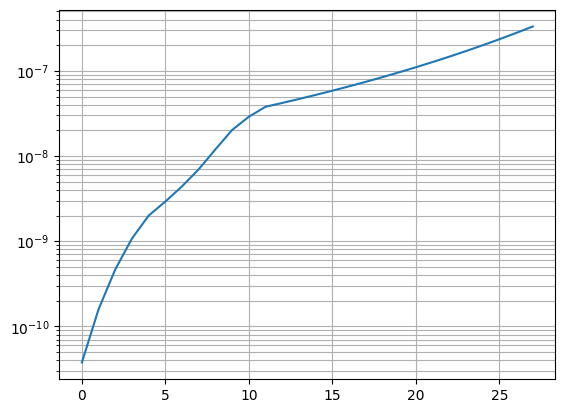

In [5]:
# print(len(energy_groups_center))
print(len(energy_groups_boundaries))
plt.plot(energy_groups_boundaries)
plt.yscale('log')
plt.grid(which="both")
plt.show()